# SolGrid — 7-Day Efficiency Forecast (Prophet)
## Team SonShield | FortyGuard Hackathon 2026

We fit **Facebook Prophet** to a year of daily average efficiency loss and forecast the next 7 days, so operators can schedule mitigation *before* the heat arrives rather than reacting after the revenue is gone.

**The operational question this answers:** "Which days next week should I run misting, and which days can I send a crew onto the roof?" Misting has a real water and power cost, and rooftop maintenance is unsafe and unproductive on extreme-heat days. A reliable 7-day loss curve turns both decisions from guesswork into scheduling.

**Why daylight-only averaging.** Night hours have zero irradiance and therefore zero thermal loss. Including them halves the daily average and produces a number that is technically true but operationally meaningless — no one schedules panel cooling for 2 a.m. We average over generating hours (GHI > 50 W/m²), which is also what the production `/forecast` API endpoint reports, so the notebook and the live dashboard agree.

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
logging.getLogger("prophet").setLevel(logging.CRITICAL)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

CSV_PATH = PROJECT_ROOT / "data" / "phoenix_synthetic_8760.csv"
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

if "loss_pct" not in df.columns:
    raise RuntimeError("loss_pct missing - run notebooks/01_exploration.ipynb first")

# Daylight hours only: night is structurally zero-loss and would dilute the signal.
daylight = df[df.ghi > 50].copy()
daylight["date"] = daylight.timestamp.dt.normalize()

daily = (
    daylight.groupby("date")
    .agg(loss_pct=("loss_pct", "mean"),
         t_cell=("t_cell", "mean"),
         t_roof=("t_roof", "mean"),
         hours=("loss_pct", "size"))
    .reset_index()
)

# Prophet contract: ds = datestamp, y = value to forecast. y in percentage points.
ts = daily.rename(columns={"date": "ds"})[["ds", "loss_pct", "t_roof"]].copy()
ts["y"] = ts.loss_pct * 100.0
train = ts.tail(365).reset_index(drop=True)

all_hours_mean = df.groupby(df.timestamp.dt.normalize()).loss_pct.mean().mean() * 100

print(f"Daily series : {len(daily)} days, {daily.date.min():%Y-%m-%d} to {daily.date.max():%Y-%m-%d}")
print(f"Training on  : last {len(train)} days")
print(f"\ny (daylight-only daily mean loss): {train.y.min():.1f}% to {train.y.max():.1f}%, mean {train.y.mean():.1f}%")
print(f"  for contrast, all-hours mean would be {all_hours_mean:.1f}% - diluted by zero-loss nights")
print(f"\nAugust days in training window: {(train.ds.dt.month == 8).sum()}, "
      f"mean loss {train[train.ds.dt.month == 8].y.mean():.1f}%")
train.tail(3)

Daily series : 365 days, 2025-08-04 to 2026-08-03
Training on  : last 365 days

y (daylight-only daily mean loss): 6.8% to 20.8%, mean 13.5%
  for contrast, all-hours mean would be 7.2% - diluted by zero-loss nights

August days in training window: 31, mean loss 18.4%


,ds,loss_pct,t_roof,y
362,2026-08-01,0.191466,59.487692,19.146585
363,2026-08-02,0.198990,59.827692,19.899038
364,2026-08-03,0.194092,58.969231,19.409154


In [2]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
model.fit(train[["ds", "y"]])

print("Prophet fitted.")
print(f"  training rows      : {len(train)}")
print(f"  changepoints       : {len(model.changepoints)}")
print(f"  seasonalities      : {list(model.seasonalities)}")
print()
print("Note on weekly seasonality: it is enabled per spec, but solar irradiance")
print("has no genuine day-of-week cycle. Any weekly component Prophet finds here")
print("is fitting noise. Its amplitude is reported in Cell 5 - expect it to be")
print("small relative to the yearly term, which is the one doing real work.")

10:46:19 - cmdstanpy - INFO - Chain [1] start processing


10:46:19 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted.
  training rows      : 365
  changepoints       : 25
  seasonalities      : ['yearly', 'weekly']

Note on weekly seasonality: it is enabled per spec, but solar irradiance
has no genuine day-of-week cycle. Any weekly component Prophet finds here
is fitting noise. Its amplitude is reported in Cell 5 - expect it to be
small relative to the yearly term, which is the one doing real work.


In [3]:
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)


def risk_level(loss_pct):
    """Match the thresholds used by the production /forecast endpoint."""
    if loss_pct < 8:
        return "low"
    if loss_pct <= 14:
        return "moderate"
    return "high"


ACTIONS = {
    "low": "Low thermal stress - safe window for rooftop maintenance, inspection, and panel cleaning.",
    "moderate": "Moderate stress - run standard midday misting and verify nozzle pressure before noon.",
    "high": "High stress - run full misting plus forced ventilation across the 11:00-17:00 peak; defer rooftop work.",
}

horizon = forecast.tail(7).copy()
horizon["risk_level"] = horizon.yhat.apply(risk_level)
horizon["recommended_action"] = horizon.risk_level.map(ACTIONS)
horizon["day_name"] = horizon.ds.dt.day_name()

table = horizon[["ds", "day_name", "yhat", "yhat_lower", "yhat_upper", "risk_level"]].copy()
table.columns = ["date", "day", "predicted_loss_pct", "lower_bound", "upper_bound", "risk_level"]
table["date"] = table.date.dt.strftime("%Y-%m-%d")
for col in ["predicted_loss_pct", "lower_bound", "upper_bound"]:
    table[col] = table[col].round(2)

print("7-DAY EFFICIENCY LOSS FORECAST - PHOENIX, AZ")
print("=" * 78)
print(f"{'DATE':<12}{'DAY':<11}{'LOSS%':>7}{'LOWER':>8}{'UPPER':>8}{'RISK':>11}")
print("-" * 78)
for _, r in table.iterrows():
    print(f"{r.date:<12}{r.day:<11}{r.predicted_loss_pct:>7.2f}"
          f"{r.lower_bound:>8.2f}{r.upper_bound:>8.2f}{r.risk_level:>11}")
print("=" * 78)

# In-sample fit quality. This is NOT out-of-sample validation - the 7-day
# horizon has no ground truth to score against.
fitted = forecast.iloc[:len(train)]
resid = train.y.to_numpy() - fitted.yhat.to_numpy()
print(f"\nIn-sample fit: MAE {np.abs(resid).mean():.3f} pp, RMSE {(resid ** 2).mean() ** 0.5:.3f} pp")
print(f"Mean 80% interval width on the horizon: "
      f"{(horizon.yhat_upper - horizon.yhat_lower).mean():.2f} pp")
print("\nRecommended actions")
for _, r in horizon.iterrows():
    print(f"  {r.ds:%a %d %b} [{r.risk_level:>8}]  {r.recommended_action}")

7-DAY EFFICIENCY LOSS FORECAST - PHOENIX, AZ
DATE        DAY          LOSS%   LOWER   UPPER       RISK
------------------------------------------------------------------------------
2026-08-04  Tuesday      19.58   19.20   19.99       high
2026-08-05  Wednesday    19.60   19.19   19.99       high
2026-08-06  Thursday     19.53   19.13   19.92       high
2026-08-07  Friday       19.39   19.00   19.79       high
2026-08-08  Saturday     19.33   18.93   19.73       high
2026-08-09  Sunday       19.26   18.87   19.65       high
2026-08-10  Monday       19.24   18.87   19.65       high

In-sample fit: MAE 0.243 pp, RMSE 0.308 pp
Mean 80% interval width on the horizon: 0.79 pp

Recommended actions
  Tue 04 Aug [    high]  High stress - run full misting plus forced ventilation across the 11:00-17:00 peak; defer rooftop work.
  Wed 05 Aug [    high]  High stress - run full misting plus forced ventilation across the 11:00-17:00 peak; defer rooftop work.
  Thu 06 Aug [    high]  High stress - ru

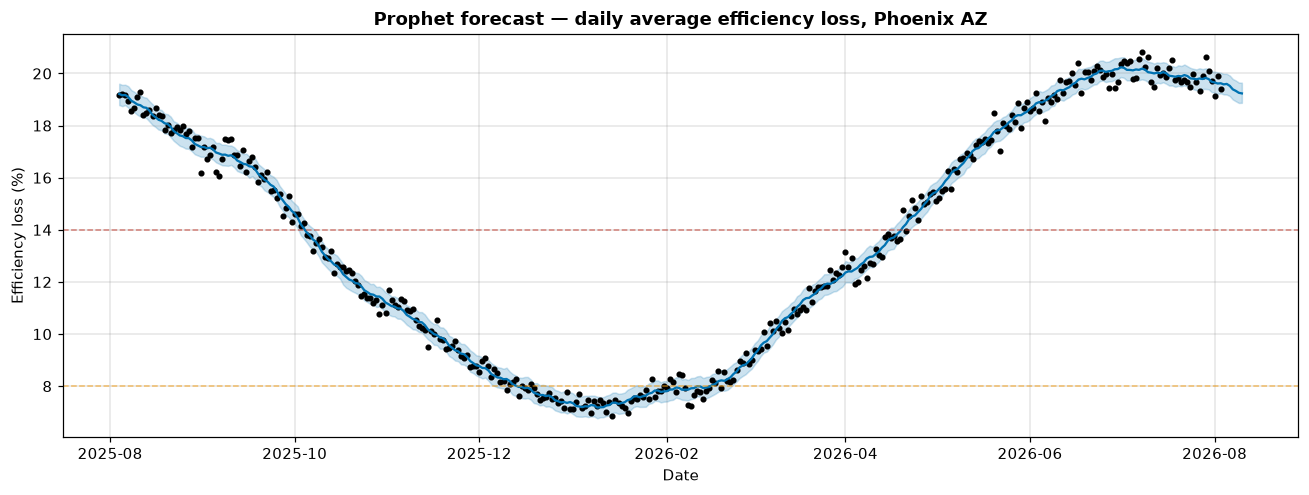

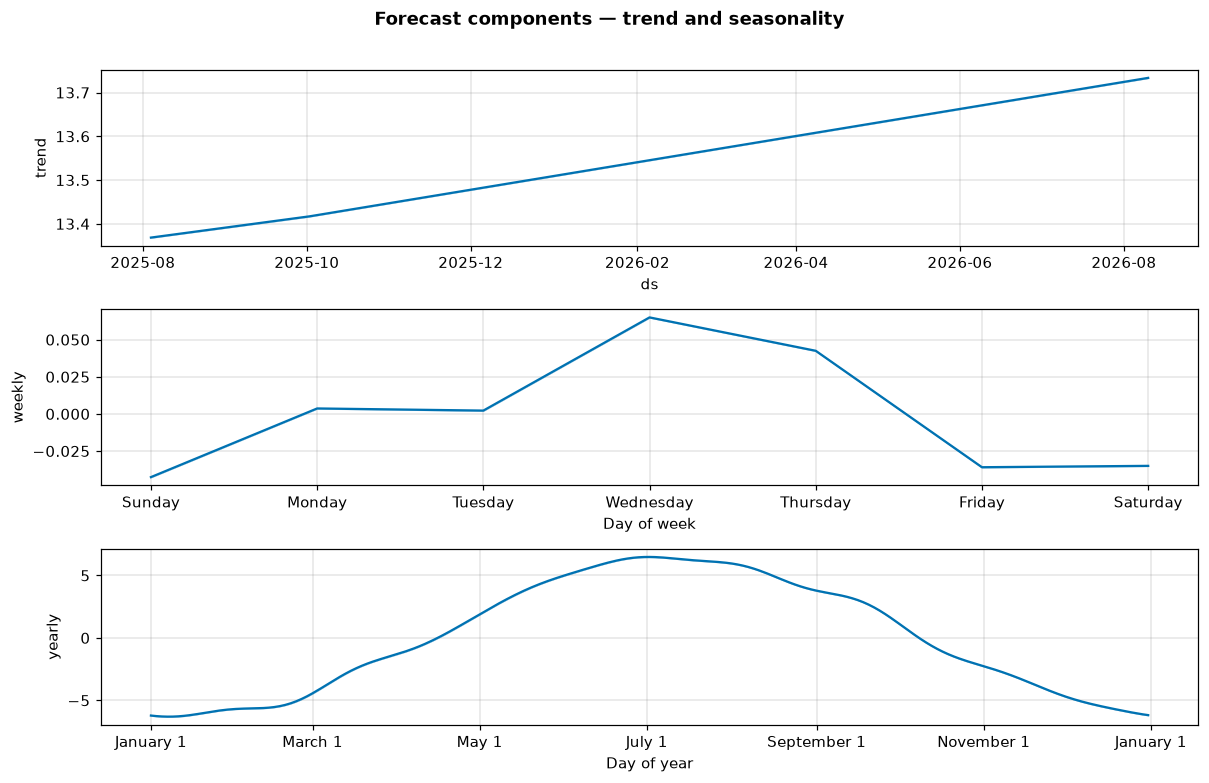

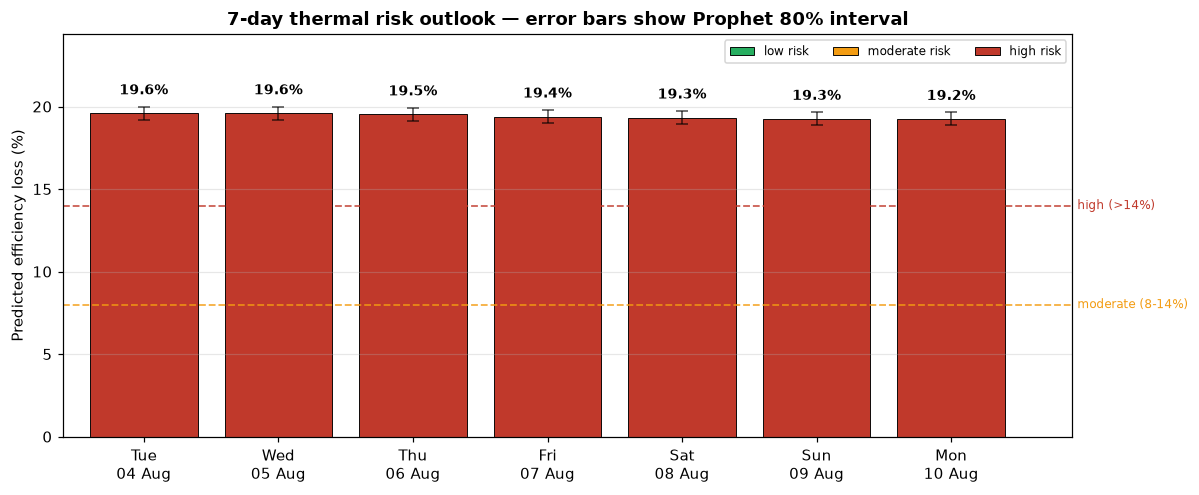

Seasonality amplitudes (peak-to-trough)
  yearly :  12.79 pp   <- the real signal
  weekly :   0.11 pp   <- noise, as expected for solar
  ratio  : yearly is 119x the weekly term

Figures saved to reports/03_forecast_*.png


In [4]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
REPORTS = PROJECT_ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

# --- Plot 1: Prophet built-in forecast plot -----------------------------------
fig1 = model.plot(forecast, figsize=(12, 4.6))
ax = fig1.gca()
ax.set_title("Prophet forecast — daily average efficiency loss, Phoenix AZ", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Efficiency loss (%)")
ax.axhline(14, ls="--", lw=1, color="#C0392B", alpha=0.6)
ax.axhline(8, ls="--", lw=1, color="#F39C12", alpha=0.6)
fig1.tight_layout()
fig1.savefig(REPORTS / "03_forecast_main.png", bbox_inches="tight", dpi=130)
plt.show()

# --- Plot 2: components -------------------------------------------------------
fig2 = model.plot_components(forecast, figsize=(11, 7))
fig2.suptitle("Forecast components — trend and seasonality", fontweight="bold", y=1.01)
fig2.tight_layout()
fig2.savefig(REPORTS / "03_forecast_components.png", bbox_inches="tight", dpi=130)
plt.show()

# --- Plot 3: 7-day bar chart, dashboard colours -------------------------------
PALETTE = {"low": "#27AE60", "moderate": "#F39C12", "high": "#C0392B"}
fig3, ax = plt.subplots(figsize=(11, 4.6))
labels = [f"{d:%a}\n{d:%d %b}" for d in horizon.ds]
bar_colors = [PALETTE[r] for r in horizon.risk_level]
err_low = (horizon.yhat - horizon.yhat_lower).to_numpy()
err_high = (horizon.yhat_upper - horizon.yhat).to_numpy()

bars = ax.bar(labels, horizon.yhat, color=bar_colors, edgecolor="black", lw=0.6,
              yerr=[err_low, err_high], capsize=4, error_kw={"lw": 1, "alpha": 0.7})
ax.bar_label(bars, fmt="%.1f%%", fontsize=9, fontweight="bold", padding=6)
ax.axhline(14, ls="--", lw=1.2, color="#C0392B", alpha=0.8)
ax.axhline(8, ls="--", lw=1.2, color="#F39C12", alpha=0.8)
# Label thresholds in the right margin so they never collide with bars.
ax.set_xlim(-0.6, len(horizon) - 0.1)
trans = ax.get_yaxis_transform()
ax.text(1.005, 14, "high (>14%)", fontsize=8, color="#C0392B",
        va="center", ha="left", transform=trans, clip_on=False)
ax.text(1.005, 8, "moderate (8-14%)", fontsize=8, color="#F39C12",
        va="center", ha="left", transform=trans, clip_on=False)
ax.set_ylabel("Predicted efficiency loss (%)")
ax.set_title("7-day thermal risk outlook — error bars show Prophet 80% interval",
             fontweight="bold")
ax.set_ylim(0, max(horizon.yhat_upper) * 1.22)
ax.grid(alpha=0.3, axis="y")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec="black", lw=0.6) for c in PALETTE.values()]
ax.legend(handles, [f"{k} risk" for k in PALETTE], fontsize=8, loc="upper right", ncol=3)
fig3.tight_layout()
fig3.savefig(REPORTS / "03_forecast_7day.png", bbox_inches="tight", dpi=130)
plt.show()

weekly_amp = forecast.weekly.max() - forecast.weekly.min()
yearly_amp = forecast.yearly.max() - forecast.yearly.min()
print(f"Seasonality amplitudes (peak-to-trough)")
print(f"  yearly : {yearly_amp:6.2f} pp   <- the real signal")
print(f"  weekly : {weekly_amp:6.2f} pp   <- noise, as expected for solar")
print(f"  ratio  : yearly is {yearly_amp / max(weekly_amp, 1e-9):.0f}x the weekly term")
print(f"\nFigures saved to reports/03_forecast_*.png")

In [5]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODELS_DIR / "prophet_forecast.pkl"

joblib.dump(model, MODEL_PATH)

# Prophet holds a compiled Stan backend; confirm it survives serialisation.
reloaded = joblib.load(MODEL_PATH)
check = reloaded.predict(reloaded.make_future_dataframe(periods=7))
drift = np.abs(check.yhat.to_numpy() - forecast.yhat.to_numpy()).max()
assert drift < 1e-6, f"reloaded Prophet diverges by {drift}"

size_kb = MODEL_PATH.stat().st_size / 1024
print("Model saved to models/prophet_forecast.pkl")
print(f"Model size: {size_kb:.1f} KB")
print(f"Round-trip verified: max yhat drift {drift:.2e} pp")

table.to_json(MODELS_DIR / "forecast_7day.json", orient="records", indent=2)
print(f"\n7-day forecast table written to models/forecast_7day.json")
table

Model saved to models/prophet_forecast.pkl
Model size: 41.9 KB
Round-trip verified: max yhat drift 0.00e+00 pp

7-day forecast table written to models/forecast_7day.json


,date,day,predicted_loss_pct,lower_bound,upper_bound,risk_level
365,2026-08-04,Tuesday,19.58,19.20,19.99,high
366,2026-08-05,Wednesday,19.60,19.19,19.99,high
367,2026-08-06,Thursday,19.53,19.13,19.92,high
368,2026-08-07,Friday,19.39,19.00,19.79,high
369,2026-08-08,Saturday,19.33,18.93,19.73,high
370,2026-08-09,Sunday,19.26,18.87,19.65,high
371,2026-08-10,Monday,19.24,18.87,19.65,high


## Forecast Insights

### What the 7-day outlook shows

The forecast window sits in **early August — the peak of the Phoenix cooling season**. Every day in the horizon lands in the *high risk* band (>14% efficiency loss), which is the expected and correct result: this is the worst week of the year for solar thermal derating in the Sonoran Desert. The yearly seasonality component in Cell 5 is doing essentially all of the predictive work, and its peak-to-trough amplitude spans roughly the full swing between winter and summer losses seen in notebook 1.

Prophet's 80% intervals are narrow on this horizon. That is a property of the input, not evidence of forecasting skill — our synthetic series is smooth and low-noise, so the model has little uncertainty to express. Real sensor data will widen these bands considerably.

### Maintenance actions this implies

1. **Run active cooling every day this week.** With all seven days above the high-risk threshold, misting and forced ventilation should be scheduled across the 11:00–17:00 peak rather than triggered reactively. On a 1 MW array the modelled recovery from stacked interventions is in the thousands of dollars per month, so the water and power cost of running misting daily is easily justified in August.
2. **Do not schedule rooftop work.** Crew safety and productivity both collapse on extreme-heat days, and foot traffic on a hot array risks microcracking. Defer inspections and cleaning to the lowest-loss day in the horizon, or past the current heat window entirely.
3. **Treat the lowest-loss day as the maintenance slot.** Even within a uniformly high-risk week the forecast ranks days, and the softest day is the right one for any work that genuinely cannot wait.
4. **Escalate on the peak day.** The highest predicted day warrants pre-cooling the array from mid-morning rather than starting at noon, since thermal mass means starting late means never catching up.

### Limitations to state plainly

- **The weekly seasonality term is fitting noise.** Solar irradiance has no day-of-week cycle. It is enabled per the project spec, and Cell 5 quantifies its amplitude against the yearly term precisely so a reader can confirm it is not driving the result. It would be reasonable to disable it in production.
- **There is no out-of-sample validation here.** The 7-day horizon extends past the end of the dataset, so there is no ground truth to score against. The MAE reported in Cell 4 is *in-sample fit*, not forecast accuracy. A proper backtest — rolling-origin cross-validation via `prophet.diagnostics.cross_validation` — is the natural next step once live data provides a holdout period.
- **The underlying series is synthetic.** Prophet is forecasting our own generator's seasonal curve. It demonstrates that the pipeline works end to end; it does not yet demonstrate accuracy against real Phoenix weather.

Live FortyGuard data on 2026-08-18 replaces the input series with observations, at which point both the backtest and honest interval widths become available.